### Corrective RAG (CRAG)

- RAG 시스템에서 검색된 문서가 부족하거나 관련성이 낮을 때 발생하는 환각(Hallucination) 현상을 완화하기 위해 설계된 방법론
- 검색된 문서의 품질을 평가하고, 그 결과에 따라 검색 전략을 동적으로 수정(Corrective Action)

In [3]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [21]:
from langchain import hub # 랭체인의 허브 기능으로 사전 정의된 체인, 도구, 프롬프트 등을 사용

prompt = hub.pull("rlm/rag-prompt")

generation_chain = prompt | llm

In [22]:
prompt

ChatPromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, metadata={'lc_hub_owner': 'rlm', 'lc_hub_repo': 'rag-prompt', 'lc_hub_commit_hash': '50442af133e61576e74536c6556cefe1fac147cad032f4377b60c436e6cdcb6e'}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template="You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.\nQuestion: {question} \nContext: {context} \nAnswer:"), additional_kwargs={})])

In [23]:
from langchain_community.document_loaders import WebBaseLoader # 웹에서 데이터를 가져옵니다

urls = [
    "https://www.promptingguide.ai/kr",
    "https://www.promptingguide.ai/kr/introduction/basics",
] # 텍스트 데이터를 가져올 웹 페이지의 URL 목록

docs = [WebBaseLoader(url).load() for url in urls]
docs_list = [item for sublist in docs for item in sublist] # 중첩된 리스트(List of Lists)를 단일(Flat) 리스트로 평탄화(Flattening)하는 기능

In [24]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

# 문서 분할
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=512,
    chunk_overlap=0,
)
doc_splits = text_splitter.split_documents(docs_list)

In [25]:
doc_splits

[Document(metadata={'source': 'https://www.promptingguide.ai/kr', 'title': '프롬프트 엔지니어링 가이드 | Prompt Engineering Guide<!-- --> ', 'language': 'kr'}, page_content='프롬프트 엔지니어링 가이드 | Prompt Engineering Guide<!-- --> 🚀 Master Prompt Engineering and building AI Agents in our NEW courses! Use PROMPTING20 for 20% off ➜ Enroll nowPrompt Engineering GuideAboutAboutGitHubGitHub (opens in a new tab)DiscordDiscord (opens in a new tab)Prompt EngineeringIntroductionLLM 설정프롬프트의 기초프롬프트의 구성 요소프롬프트 설계에 관한 일반적인 팁프롬프트 예시TechniquesZero-shot PromptingFew-shot PromptingChain-of-Thought PromptingSelf-ConsistencyGenerate Knowledge PromptingPrompt ChainingTree of ThoughtsRetrieval Augmented'),
 Document(metadata={'source': 'https://www.promptingguide.ai/kr', 'title': '프롬프트 엔지니어링 가이드 | Prompt Engineering Guide<!-- --> ', 'language': 'kr'}, page_content='GenerationAutomatic Reasoning and Tool-useAutomatic Prompt EngineerActive-PromptDirectional Stimulus PromptingProgram-Aided Language ModelsReActReflexionMultimoda

In [26]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from dotenv import load_dotenv
load_dotenv()

# 임베딩 모델 준비
embedding_model = GoogleGenerativeAIEmbeddings(
    model="gemini-embedding-001",
)

In [ ]:
from langchain_community.vectorstores import FAISS

# FAISS 벡터스토어 생성 및 저장
vectorstore = FAISS.from_documents(doc_splits, embedding_model)
vectorstore.save_local("faiss_web")

# 벡터스토어 재로딩
vectorstore = FAISS.load_local(
    "faiss_web",
    embedding_model,
    allow_dangerous_deserialization=True, # 완전히 신뢰할 수 있는 경우(자신이 직접 저장한 파일)에만 매우 신중하게 사용
)

In [43]:
# retriever = vectorstore.as_retriever(search_kwargs={"k": 2}) # 벡터 저장소를 검색할 수 있는 검색기(retriever) 생성
retriever = vectorstore.as_retriever()

In [44]:
retriever

VectorStoreRetriever(tags=['FAISS', 'GoogleGenerativeAIEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x0000021E9CC2B4D0>, search_kwargs={})

In [45]:
from typing_extensions import TypedDict # 딕셔너리의 구조와 데이터 타입을 명시적으로 정의
from typing import List

class GraphState(TypedDict): # 데이터의 상태를 표현한 딕셔너리 구조
    question : str
    generation : str
    web_search : str
    documents : List[str] # 문서 데이터를 문자열의 리스트로 저장

In [46]:
from typing import Any, Dict

def retrieve(state: GraphState) -> Dict[str, Any]: # 질문과 검색된 문서가 포함된 딕셔너리를 반환
    print("---검색---")
    question = state["question"]

    documents = retriever.invoke(question) # retriever를 사용하여 저장소에서 관련 문서를 검색
    return {"documents": documents, "question": question}

In [47]:
from langchain.prompts import PromptTemplate # LLM에 제공할 프롬프트를 템플릿 형식으로 정의
from langchain_core.output_parsers import JsonOutputParser # LLM에서 생성된 출력값을 JSON 형식으로 파싱
prompt = PromptTemplate(
    template="""<|begin_of_text|><|start_header_id|>system<|end_header_id|> 당신은 사용자의 질문과 검색된 문서의 관련성을 평가하는 봇입니다. 문서에 사용자의 질문과 관련된 키워드가 포함되어 있다면, 이를 관련성이 있다고 평가하세요.
문서가 질문과 관련이 있는지 여부를 나타내기 위해 'yes' 또는 'no'의 점수를 부여하세요.
점수는 'score'라는 단일 키를 포함하는 JSON 형식으로 제공하되 추가 설명이나 서문 없이 작성하세요.
     <|eot_id|><|start_header_id|>user<|end_header_id|>
    여기에 검색된 문서가 있습니다: \n\n {document} \n\n
    여기에 사용자 질문이 있습니다: {question} \n <|eot_id|><|start_header_id|>assistant<|end_header_id|>
    """,
    input_variables=["question", "document"],
) # LLM이 작업을 수행하기 위한 지침

retrieval_grader = prompt | llm | JsonOutputParser()


In [50]:
def relevant_documents(state: GraphState) -> Dict[str, Any]:
    print("---문서가 질문과 관련이 있는지 확인하세요---")
    question = state["question"]
    documents = state["documents"]

    filtered_docs = []
    web_search = False
    for d in documents:
        score = retrieval_grader.invoke({"question": question, "document": d.page_content}) # retrieval_grader를 호출하여 질문(question)과 문서의 텍스트(d.page_content) 간 관련성을 평가
        grade = score['score']
        if grade.lower() == "yes": # 문서 필터
            print("---평가: 관련 있음---")
            filtered_docs.append(d)
        else:
            print("---평가: 관련 없음---")

    if len(filtered_docs) == 0: # 웹 검색 여부 결정
        web_search = True

    return {"documents": filtered_docs, "question": question, "web_search": web_search}


In [60]:
from langchain_core.tools import tool
from langchain_community.utilities import DuckDuckGoSearchAPIWrapper
from langchain_community.tools import DuckDuckGoSearchResults 

@tool
def get_web_search(query: str, search_period: str='w') -> str:
    """
    웹 검색을 수행하는 함수.

    Args:
        query (str): 검색어
        search_period (str): 검색 기간 (e.g., "w" for past week (default), "m" for past month, "y" for past year, "d" for past day)

    Returns:
        str: 검색 결과
    """
    wrapper = DuckDuckGoSearchAPIWrapper(
        region="kr-kr",
        time=search_period
    )

    print('\n----- WEB SEARCH -----')
    print(query)
    print(search_period)

    search = DuckDuckGoSearchResults(
        api_wrapper=wrapper,
        source="news",
        results_separator=';\n'
    )

    searched = search.invoke(query)
    
    for i, result in enumerate(searched.split(';\n')):
        print(f'{i+1}. {result}')
    
    return searched

In [67]:
result = get_web_search.invoke("랭그래프란 무엇인가?")


----- WEB SEARCH -----
랭그래프란 무엇인가?
w
1. snippet: 1. 질오르가즘이란 무엇인가 . 이 글을 읽는 여러분이 남성이라면, 상대 여성이 #오르가즘 을 느낄 줄 아는 여성인지 아닌지에 대해서만 궁금해하는 것은 곤란해., title: 질오르가즘이란 무엇인가 1부 : 네이버 블로그, link: https://m.blog.naver.com/PostView.nhn?blogId=neonbambi&logNo=221255111096&targetKeyword=&targetRecommendationCode=1
2. snippet: Home » 검색엔진 최적화 » HTML 태그란 무엇인가 ? – 구성 요소와 속성., title: HTML 태그란 무엇인가 ? - 구성 요소와 속성 | TBWA 데이터랩, link: https://seo.tbwakorea.com/blog/what-is-a-tag/
3. snippet: 문화. 테이쇼쿠란 무엇인가 ? 일본의 정식. Malia Marshall Ogawa 작성., title: 테이쇼쿠란 무엇인가 ? 일본의 유명한 정식 알아보기, link: https://www.byfood.com/ko/blog/teishoku-japanese-set-meal-p-715
4. snippet: “생명이란 무엇인가 ?” 이 의문은 오랜 동안 인류의 큰 관심사였다. 끝을 알 수 없는 이 질문은 철학과 종교 그리고 예술의 영역이었다., title: 생명이란 무엇인가 – 린 마굴리스, 도리언 세이건, link: https://www.sciencepeople.co.kr/생명이란-무엇인가-린-마굴리스-도리언-세이건/


In [68]:
type(result)

str

In [71]:
from langchain.schema import Document

def websearch(state: GraphState) -> Dict[str, Any]: # 검색된 문서와 질문을 포함하는 딕셔너리를 반환
    print("---웹에서 검색---")
    question = state["question"]
    documents = state["documents"] # 현재 상태에서 관리 중인 문서 리스트를 가져옵니다

    web_results = get_web_search.invoke({"query": question}) # 검색 도구 호출
    # web_results = Document(page_content=web_results) # 검색 결과 처리
    if documents is not None: # 기존 문서 리스트(documents)가 있으면 새로 생성된 검색 결과(web_results)를 추가
        documents.append(web_results)
    else:
        documents = [web_results]
    return {"documents": documents, "question": question}


In [72]:
def write(state: GraphState) -> Dict[str, Any]: # 현재 상태(GraphState)에서 질문과 문서를 추출
    print("---답변 생성---")
    question = state["question"]
    documents = state["documents"]

    generation = generation_chain.invoke({"context": documents, "question": question}) # generation_chain을 호출하여 문서(context)와 질문(question)을 입력으로 답변 생성
    return {"documents": documents, "question": question, "generation": generation}


In [73]:
def decide_to_write(state):
    print("---문서 검토---")

    if state["web_search"]: # 웹 검색 여부 판단
        print(
            "---decide: 모든 문서가 질문과 관련이 있는 것은 아니므로 웹 검색을 포함합니다---"
        )
        return WEBSEARCH
    else:
        print("---write: 답변을 생성합니다---")
        return WRITE

In [74]:
RETRIEVE = "retrieve" # 데이터를 검색
RELEVANT_DOCUMENTS = "relevant_documents" # 검색된 문서를 평가
WRITE = "write"
WEBSEARCH = "websearch"

In [75]:
from langgraph.graph import END, StateGraph
workflow = StateGraph(GraphState)

# 노드 이름과 연결된 함수를 매핑
workflow.add_node(RETRIEVE, retrieve) # 문서 검색에는 retrieve 함수 실행
workflow.add_node(RELEVANT_DOCUMENTS, relevant_documents)
workflow.add_node(WRITE, write)
workflow.add_node(WEBSEARCH, websearch)

workflow.set_entry_point(RETRIEVE) # 워크플로우의 시작 노드를 설정
workflow.add_edge(RETRIEVE, RELEVANT_DOCUMENTS) # RETRIEVE → RELEVANT_DOCUMENTS: 검색된 문서를 평가하는 단계로 전환
workflow.add_conditional_edges(
    RELEVANT_DOCUMENTS, # 출발 노드
    decide_to_write, # 조건부 상태 전이
    {
        WEBSEARCH: WEBSEARCH, # 추가 검색 필요 시 WEBSEARCH로 이동
        WRITE: WRITE, # 문서 평가 결과가 충분하면 WRITE로 이동
    },
)
workflow.add_edge(WEBSEARCH, WRITE)
workflow.add_edge(WRITE, END) # 작업 종료

app = workflow.compile() # 정의된 워크플로우를 컴파일하여 실행 가능한 상태로 만듭니다


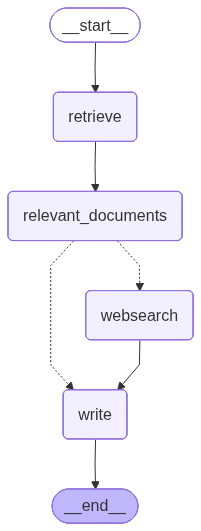

In [76]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png())) # 정의된 워크플로우(app)의 그래프를 가져와 PNG 이미지로 변환
except Exception:
    pass

In [77]:
from pprint import pprint
inputs = {"question": "프롬프트 엔지니어링이란?"} # 워크폴로우 실행에 필요한 입력 데이터
for output in app.stream(inputs): # 스트리밍 방식으로 결과를 생성
    for key, value in output.items():
        pprint(f"Finished running: {key}:")
pprint(value["generation"])

---검색---
'Finished running: retrieve:'
---문서가 질문과 관련이 있는지 확인하세요---
---평가: 관련 있음---
---평가: 관련 있음---
---평가: 관련 있음---
---평가: 관련 있음---
---문서 검토---
---write: 답변을 생성합니다---
'Finished running: relevant_documents:'
---답변 생성---
'Finished running: write:'
AIMessage(content='프롬프트 엔지니어링은 언어 모델(LM)을 다양한 애플리케이션과 연구 주제에 효율적으로 사용할 수 있도록 프롬프트를 개발하고 최적화하는 분야입니다. 이는 LLM과 상호 작용하고 개발하는 데 유용한 다양한 기술과 기법을 포함합니다. 이 기술은 LLM의 기능과 한계를 이해하고, LLM을 기반으로 새로운 기능을 구축하는 데 중요합니다.', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run--76654c4a-6d13-4097-8323-4eb94d5bd567-0', usage_metadata={'input_tokens': 1037, 'output_tokens': 475, 'total_tokens': 1512, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 384}})


In [79]:
from pprint import pprint
inputs = {"question": "KT 소액결제 해킹사건의 원인은?"} # 워크폴로우 실행에 필요한 입력 데이터
for output in app.stream(inputs): # 스트리밍 방식으로 결과를 생성
    for key, value in output.items():
        pprint(f"Finished running: {key}:")
pprint(value["generation"])

---검색---
'Finished running: retrieve:'
---문서가 질문과 관련이 있는지 확인하세요---
---평가: 관련 없음---
---평가: 관련 없음---
---평가: 관련 없음---
---평가: 관련 없음---
---문서 검토---
---decide: 모든 문서가 질문과 관련이 있는 것은 아니므로 웹 검색을 포함합니다---
'Finished running: relevant_documents:'
---웹에서 검색---

----- WEB SEARCH -----
KT 소액결제 해킹사건의 원인은?
w
1. snippet: 6 days ago - KT 소액결제 해킹 사기 사건과 관련해 국내에서 활동한 피의자들이 검찰에 넘겨졌습니다. 경기남부경찰청 사이버수사대는 오늘 중국 국적 40대 남성 장 모 씨와 류 모 씨를 구속 상태..., title: MBC 뉴스 'KT 소액결제' 중국 국적 피의자 3명 오늘 검찰 송치, link: https://imnews.imbc.com/news/2025/society/article/6759819_36718.html
2. snippet: 6 days ago - 경찰이 KT ‘무단 소액결제 ’사건의 중국 국적 피의자 2명을 25일 검찰에 넘기지만 아직도 사건 전체의 윤곽은 안갯속에 묻혀 있다. 범행의 몸통 역할을 한 윗선의 정체, 집단 소액결제에 성공할 수 있었던 범행 기법 등 산적한 ..., title: Dt ‘무단 소액결제’ 의혹 더 커졌다…KT 펨토셀 아닌 불법 장비 사용, 인증서 해킹 정황 | 디지털타임스, link: https://www.dt.co.kr/article/12020257
3. snippet: 1 week ago - (수원=연합뉴스) 강영훈 김솔 기자 = KT 무단 소액결제 사건을 수사해 온 경찰이 피의자인 중국 국적의 남성들을 구속 상태로 25일 검찰에 넘..., title: Yonhap News Agency 경찰, KT 소액결제 사건 피의자 중국인 2명 내일 구속 송치(종합) | 연합뉴스, li